In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.fft import fft, fftfreq

In [11]:
for r, d, files in os.walk('../data/raw'):
    for f in files:
        print(os.path.join(r, f))

../data/raw/OR007_6_1_136.mat
../data/raw/OR021_6_1_239.mat
../data/raw/Time_Normal_1_098.mat
../data/raw/IR021_1_214.mat
../data/raw/IR014_1_175.mat
../data/raw/IR007_1_110.mat
../data/raw/B021_1_227.mat
../data/raw/B014_1_190.mat
../data/raw/B007_1_123.mat
../data/raw/OR014_6_1_202.mat


In [12]:
def get_de(p):
    m = loadmat(p)
    k = [k for k in m.keys() if 'DE_time' in k][0]
    return m[k].flatten()

def get_fe(p):
    m = loadmat(p)
    keys = [k for k in m.keys() if 'FE_time' in k]
    if not keys:
        return None
    return m[keys[0]].flatten()

h = get_de('../data/raw/Time_Normal_1_098.mat')
f = get_de('../data/raw/IR007_1_110.mat')
fe_signal = get_fe('../data/raw/IR007_1_110.mat')
print(h.shape, f.shape)
print(fe_signal.shape if fe_signal is not None else "no FE channel in this dataset")

(483903,) (486224,)
(486224,)


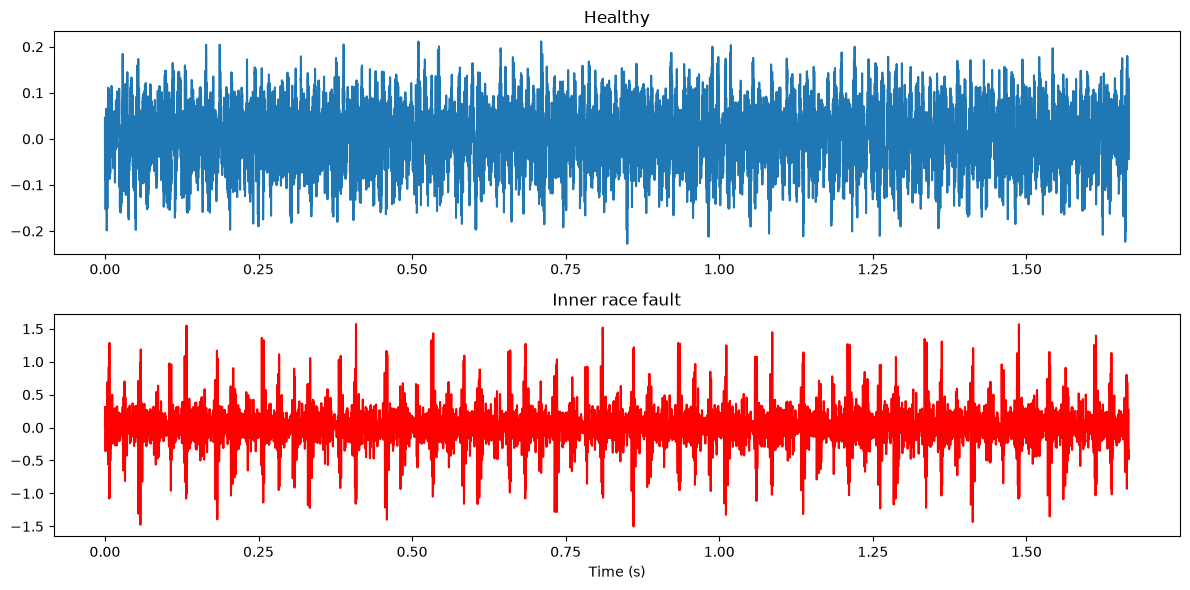

In [13]:
fs = 12000
t = np.arange(20000) / fs

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t, h[:20000]); plt.title('Healthy')

plt.subplot(2, 1, 2)
plt.plot(t, f[:20000], 'r'); plt.title('Inner race fault')
plt.xlabel('Time (s)')
plt.tight_layout(); 
plt.savefig('../reports/figures/healthy_vs_faulty_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()

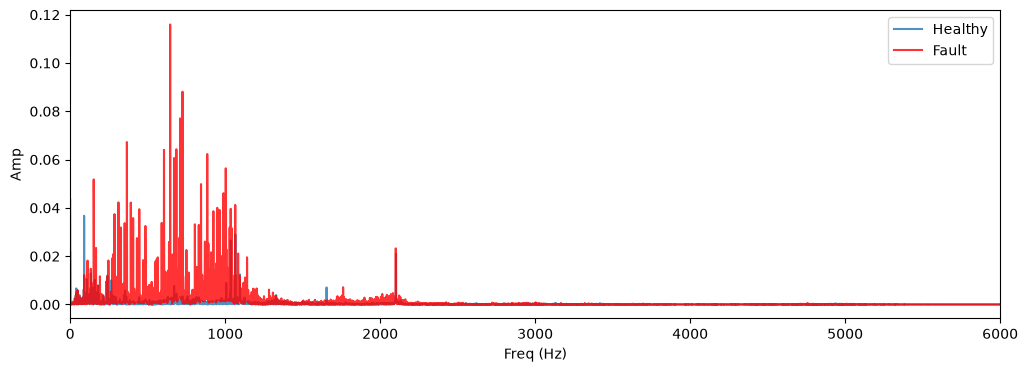

In [14]:
def get_spec(x, fs=12000, n=20000):
    x = x[:n]
    fr = fftfreq(n, 1/fs)[:n//2]
    mag = np.abs(fft(x))[:n//2] * 2/n
    return fr, mag

fh, mh = get_spec(h)
ff, mf = get_spec(f)

plt.figure(figsize=(12, 4))
plt.plot(fh, mh, label='Healthy', alpha=0.8)
plt.plot(ff, mf, 'r', label='Fault', alpha=0.8)
plt.xlabel('Freq (Hz)'); plt.ylabel('Amp')
plt.legend(); plt.xlim(0, 6000); plt.show()